In [50]:
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import pandas as pd
import keras
from tensorflow.keras.utils import to_categorical
from keras import layers

In [41]:
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [ ]:
scaler = StandardScaler()
columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
df[columns] = scaler.fit_transform(df[columns])

In [ ]:
X = df.drop(['species'], axis=1)
y = df['species']

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: species, Length: 150, dtype: int64


In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, train_size=0.80)

y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

In [48]:
model = keras.Sequential(
    [   
        layers.Dense(4, activation='relu'),
        layers.Dense(4, activation='relu'),
        layers.Dense(3, activation='softmax')
    ]
)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
print(X_train.shape)
print(y_train)

(120, 4)
22     0
15     0
65     1
11     0
42     0
      ..
71     1
106    2
14     0
92     1
102    2
Name: species, Length: 120, dtype: int64


In [49]:
history = model.fit(X_train, y_train_cat, epochs=100, batch_size=15)

Epoch 1/100


8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.3833 - loss: 2.3219
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3917 - loss: 2.1382 
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4000 - loss: 1.9679 
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4000 - loss: 1.8171 
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4583 - loss: 1.6856 
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5333 - loss: 1.5609 
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6083 - loss: 1.4528 
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6333 - loss: 1.3655 
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6500 - loss: 1.2821 
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6500 - loss: 1.2107 
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6250 - loss: 1.1517 
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6167 - loss: 1.0975 
Ep

In [56]:
model.evaluate(X_test, y_test_cat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - accuracy: 0.7667 - loss: 0.4853


[0.4852921664714813, 0.7666666507720947]

<Axes: >

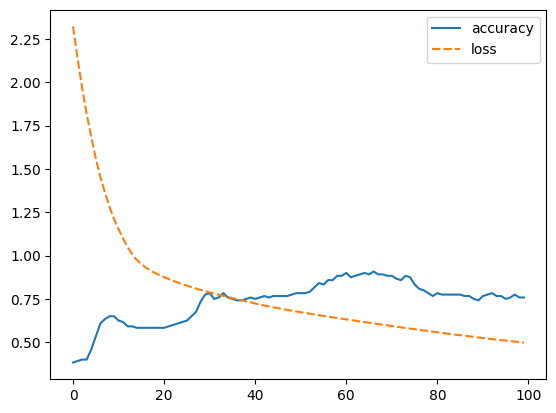

In [55]:
sns.lineplot(history.history)